In [1]:
from Swing import Swing
from dynGENIE3 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from datetime import datetime
style.use('fast')

In [2]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
gold_standard = {}
Nodes = [10, 20, 50, 100]

step = 10

list_SWING_GoldStandard = {}
list_dynGENIE3_GoldStandard = {}
list_SWING_dynGENIE3 = {}

list_SWING_GoldStandard_rand = {}
list_dynGENIE3_GoldStandard_rand = {}
list_SWING_dynGENIE3_rand = {}

list_SWING_GoldStandard_sample_rand = {}
list_dynGENIE3_GoldStandard_sample_rand = {}

list_sum_SWING_GoldStandard = {}
list_sum_dynGENIE3_GoldStandard = {}
list_sum_SWING_dynGENIE3 = {}

list_sum_SWING_GoldStandard_sample_rand = {}
list_sum_dynGENIE3_GoldStandard_sample_rand = {}

list_sum_SWING_GoldStandard_rand = {}
list_sum_dynGENIE3_GoldStandard_rand = {}
list_sum_SWING_dynGENIE3_rand = {}

for nodes in Nodes:
    
    print(nodes)
    Top = np.arange(5, 30, 5).astype(int).tolist()
    
    for top in Top:
        
        list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top{top}"] = []
        list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top{top}"] = []
        list_sum_SWING_dynGENIE3[f"list_sum_SWING_dynGENIE3_nodes{nodes}_top{top}"] = []
        
        list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top{top}_sample_rand"] = []
        list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_sample_rand"] = []
        
        list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top{top}_rand"] = []
        list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_rand"] = []
        list_sum_SWING_dynGENIE3_rand[f"list_sum_SWING_dynGENIE3_nodes{nodes}_top{top}_rand"] = []
        
        for instance in range(100):
            
            instance = instance + 1
            
            list_SWING_GoldStandard[f"list_SWING_GoldStandard_nodes{nodes}_top{top}_network{instance}"] = []
            list_dynGENIE3_GoldStandard[f"list_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_network{instance}"] = []
            list_SWING_dynGENIE3[f"list_SWING_dynGENIE3_nodes{nodes}_top{top}_network{instance}"] = []
            
            list_SWING_GoldStandard_rand[f"list_SWING_GoldStandard_nodes{nodes}_top{top}_network{instance}_rand"] = []
            list_dynGENIE3_GoldStandard_rand[f"list_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_network{instance}_rand"] = []
            list_SWING_dynGENIE3_rand[f"list_SWING_dynGENIE3_nodes{nodes}_top{top}_network{instance}_rand"] = []
            
            list_SWING_GoldStandard_sample_rand[f"list_SWING_GoldStandard_nodes{nodes}_top{top}_network{instance}_sample_rand"] = []
            list_dynGENIE3_GoldStandard_sample_rand[f"list_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_network{instance}_sample_rand"] = []
            
            sum_SWING_GoldStandard = 0
            sum_dynGENIE3_GoldStandard = 0
            sum_SWING_dynGENIE3 = 0
            
            sum_SWING_GoldStandard_rand = 0
            sum_dynGENIE3_GoldStandard_rand = 0
            sum_SWING_dynGENIE3_rand = 0
            
            sum_SWING_GoldStandard_sample_rand = 0
            sum_dynGENIE3_GoldStandard_sample_rand = 0
            
            best_SWING_top = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t").sort_values(by=["mean_importance"],ascending=False)[0:top]
            best_SWING_top_rand = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_SWING_{instance}_crand.tsv", sep ="\t").sort_values(by=["mean_importance"],ascending=False)[0:top]
            
            SWING_top = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t").sort_values(by=["mean_importance"],ascending=False)
            best_SWING_top_sample_rand = pd.DataFrame(columns = SWING_top.columns.values.tolist())
            
            for i in range(top):
                best_SWING_top_sample_rand.loc[i] = SWING_top.loc[np.random.randint(0,len(SWING_top))]
            
            #Transforming dynGENIE3 to SWING format
            best_dynGENIE3 =  pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["mean_importance"],ascending=False)[0:int(top)]
            best_dynGENIE3_rand =  pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t",names= header_list).sort_values(by=["mean_importance"],ascending=False)[0:int(top)]
            
            dynGENIE3 =  pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["mean_importance"],ascending=False)
            best_dynGENIE3_top_sample_rand_ = pd.DataFrame(columns = dynGENIE3.columns.values.tolist())
            for i in range(top):
                best_dynGENIE3_top_sample_rand_.loc[i] = dynGENIE3.loc[np.random.randint(0,len(SWING_top))]
            
            best_dynGENIE3_top = pd.DataFrame(columns = ["regulator-target", "mean_importance"])
            for i in range(top):
                n1 = best_dynGENIE3["Cause Gene"].iloc[i]
                n2 = best_dynGENIE3["Effect Gene"].iloc[i]
                n3 = best_dynGENIE3["mean_importance"].iloc[i]
                best_dynGENIE3_top.loc[i] = [f"('{n1}', '{n2}')",f"{n3}"]
                
            best_dynGENIE3_top_sample_rand = pd.DataFrame(columns = ["regulator-target", "mean_importance"])
            for i in range(top):
                n1 = best_dynGENIE3_top_sample_rand_["Cause Gene"].iloc[i]
                n2 = best_dynGENIE3_top_sample_rand_["Effect Gene"].iloc[i]
                n3 = best_dynGENIE3_top_sample_rand_["mean_importance"].iloc[i]
                best_dynGENIE3_top_sample_rand.loc[i] = [f"('{n1}', '{n2}')",f"{n3}"]    
            
            best_dynGENIE3_top_rand = pd.DataFrame(columns = ["regulator-target", "mean_importance"])
            for i in range(top):
                n1 = best_dynGENIE3_rand["Cause Gene"].iloc[i]
                n2 = best_dynGENIE3_rand["Effect Gene"].iloc[i]
                n3 = best_dynGENIE3_rand["mean_importance"].iloc[i]
                best_dynGENIE3_top_rand.loc[i] = [f"('{n1}', '{n2}')",f"{n3}"]
            
            #Transforming goldstandard to SWING format
            if nodes == 10:                                                                                                                                   
                gold_standard_ = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Networks_in_out_degree_3_num_nodes_{nodes}/in_and_out_degree_2_num_nodes_{nodes}_case_{instance}/goldstandard_signed_{instance}_goldstandard.tsv", sep="\t", names= header_list)
            else:
                gold_standard_ = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Networks_in_out_degree_3_num_nodes_{nodes}/in_and_out_degree_3_num_nodes_{nodes}_case_{instance}/goldstandard_signed_{instance}_goldstandard.tsv", sep="\t", names= header_list)
            
            gold_standard_ = gold_standard_[gold_standard_["mean_importance"] == 1]
            gold_standard = pd.DataFrame(columns = ["regulator-target", "mean_importance"])
            for i in range(len(gold_standard_)):
                n1 = gold_standard_["Cause Gene"].iloc[i]
                n2 = gold_standard_["Effect Gene"].iloc[i]
                n3 = gold_standard_["mean_importance"].iloc[i]
                gold_standard.loc[i] = [f"('{n1}', '{n2}')",f"{n3}"]
            
            # Counting and saving values agreed between SWING and goldstandard
            for i in range(top):
                for j in range(len(gold_standard)):
                    if best_SWING_top["regulator-target"].iloc[i] == gold_standard["regulator-target"].iloc[j]:
                        sum_SWING_GoldStandard = sum_SWING_GoldStandard + 1
                        list_SWING_GoldStandard[f"list_SWING_GoldStandard_nodes{nodes}_top{top}_network{instance}"].append(best_SWING_top["regulator-target"].iloc[i])
            
            list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top{top}"].append(sum_SWING_GoldStandard)
            
            # Counting and saving values agreed between SWING and goldstandard RAND
            for i in range(top):
                for j in range(len(gold_standard)):
                    if best_SWING_top_rand["regulator-target"].iloc[i] == gold_standard["regulator-target"].iloc[j]:
                        sum_SWING_GoldStandard_rand = sum_SWING_GoldStandard_rand + 1
                        list_SWING_GoldStandard_rand[f"list_SWING_GoldStandard_nodes{nodes}_top{top}_network{instance}_rand"].append(best_SWING_top_rand["regulator-target"].iloc[i])
            
            list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top{top}_rand"].append(sum_SWING_GoldStandard_rand)
            
             # Counting and saving values agreed between SWING and goldstandard SAMPLE RAND
            for i in range(top):
                for j in range(len(gold_standard)):
                    if best_SWING_top_sample_rand["regulator-target"].iloc[i] == gold_standard["regulator-target"].iloc[j]:
                        sum_SWING_GoldStandard_sample_rand = sum_SWING_GoldStandard_sample_rand + 1
                        list_SWING_GoldStandard_sample_rand[f"list_SWING_GoldStandard_nodes{nodes}_top{top}_network{instance}_sample_rand"].append(best_SWING_top_rand["regulator-target"].iloc[i])
            
            list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top{top}_sample_rand"].append(sum_SWING_GoldStandard_sample_rand)
            
            # Counting and saving values agreed between dynGENIE3 and goldstandard
            for i in range(top):
                for j in range(len(gold_standard)):
                    if best_dynGENIE3_top["regulator-target"].iloc[i] == gold_standard["regulator-target"].iloc[j]:
                        sum_dynGENIE3_GoldStandard = sum_dynGENIE3_GoldStandard + 1
                        list_dynGENIE3_GoldStandard[f"list_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_network{instance}"].append(best_dynGENIE3_top["regulator-target"].iloc[i])
            
            list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top{top}"].append(sum_dynGENIE3_GoldStandard) 
            
            # Counting and saving values agreed between dynGENIE3 and goldstandard RAND
            for i in range(top):
                for j in range(len(gold_standard)):
                    if best_dynGENIE3_top_rand["regulator-target"].iloc[i] == gold_standard["regulator-target"].iloc[j]:
                        sum_dynGENIE3_GoldStandard_rand = sum_dynGENIE3_GoldStandard_rand + 1
                        list_dynGENIE3_GoldStandard_rand[f"list_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_network{instance}_rand"].append(best_dynGENIE3_top_rand["regulator-target"].iloc[i])
            
            list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_rand"].append(sum_dynGENIE3_GoldStandard_rand) 
            
            # Counting and saving values agreed between dynGENIE3 and goldstandard SAMPLE RAND
            for i in range(top):
                for j in range(len(gold_standard)):
                    if best_dynGENIE3_top_sample_rand["regulator-target"].iloc[i] == gold_standard["regulator-target"].iloc[j]:
                        sum_dynGENIE3_GoldStandard_sample_rand = sum_dynGENIE3_GoldStandard_sample_rand + 1
                        list_dynGENIE3_GoldStandard_sample_rand[f"list_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_network{instance}_sample_rand"].append(best_dynGENIE3_top_sample_rand["regulator-target"].iloc[i])
            
            list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top{top}_sample_rand"].append(sum_dynGENIE3_GoldStandard_sample_rand) 
            
            # Counting and saving values agreed between dynGENIE3 and SWING
            for i in range(top):
                for j in range(top):
                    if best_dynGENIE3_top["regulator-target"].iloc[i] == best_SWING_top["regulator-target"].iloc[j]:
                        sum_SWING_dynGENIE3 = sum_SWING_dynGENIE3 + 1
                        list_SWING_dynGENIE3[f"list_SWING_dynGENIE3_nodes{nodes}_top{top}_network{instance}"].append(best_SWING_top["regulator-target"].iloc[j])
            
            list_sum_SWING_dynGENIE3[f"list_sum_SWING_dynGENIE3_nodes{nodes}_top{top}"].append(sum_SWING_dynGENIE3)
            
            # Counting and saving values agreed between dynGENIE3 and SWING RAND
            for i in range(top):
                for j in range(top):
                    if best_dynGENIE3_top_rand["regulator-target"].iloc[i] == best_SWING_top_rand["regulator-target"].iloc[j]:
                        sum_SWING_dynGENIE3_rand = sum_SWING_dynGENIE3_rand + 1
                        list_SWING_dynGENIE3_rand[f"list_SWING_dynGENIE3_nodes{nodes}_top{top}_network{instance}_rand"].append(best_SWING_top_rand["regulator-target"].iloc[j])
            
            list_sum_SWING_dynGENIE3_rand[f"list_sum_SWING_dynGENIE3_nodes{nodes}_top{top}_rand"].append(sum_SWING_dynGENIE3_rand)
            

10
20
50
100


 # Plots

## 10 nodes

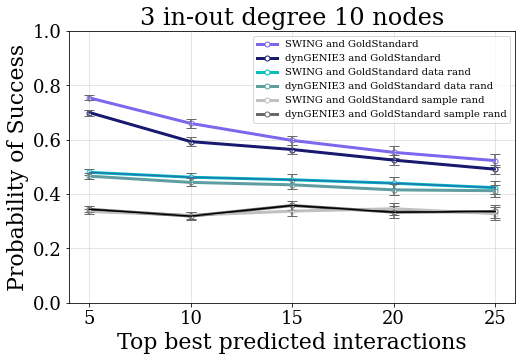

In [4]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes10_top{top}"])/top for top in Top]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes10_top{top}"])/top for top in Top]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes10_top{top}"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes10_top{top}"])/100 for top in Top]

mean_SWING_GoldStandard_rand = [mean(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes10_top{top}_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_rand = [mean(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes10_top{top}_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_rand = [std(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes10_top{top}_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_rand = [std(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes10_top{top}_rand"])/100 for top in Top]

mean_SWING_GoldStandard_sample_rand = [mean(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes10_top{top}_sample_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_sample_rand = [mean(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes10_top{top}_sample_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_sample_rand = [std(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes10_top{top}_sample_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_sample_rand = [std(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes10_top{top}_sample_rand"])/100 for top in Top]

plt.plot(Top, mean_SWING_GoldStandard, marker = "o", markersize = 5, lw = 3, color = "mediumslateblue", markerfacecolor = "w", label = "SWING and GoldStandard")
plt.errorbar(Top, mean_SWING_GoldStandard,yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray',color = "mediumslateblue")

plt.plot(Top, mean_dynGENIE3_GoldStandard, marker = "o", markersize = 5, lw =3, color = "midnightblue", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard, yerr=mean_dynGENIE3_GoldStandard_std,capsize=5,ecolor='dimgray',color = "midnightblue")

plt.errorbar(Top, mean_SWING_GoldStandard_rand, yerr=mean_SWING_GoldStandard_std_rand,capsize=5,ecolor='dimgray', lw= None)
plt.plot(Top, mean_SWING_GoldStandard_rand, marker = "o", markersize = 5, lw = 3, color = "c", markerfacecolor = "w", label = "SWING and GoldStandard data rand")

plt.plot(Top, mean_dynGENIE3_GoldStandard_rand, marker = "o", markersize = 5, lw =3, color = "cadetblue", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard data rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_rand, yerr=mean_dynGENIE3_GoldStandard_std_rand, capsize=5,ecolor='dimgray',color = "cadetblue", lw=None)

plt.plot(Top, mean_SWING_GoldStandard_sample_rand, marker = "o", markersize = 5, lw = 3, color = "silver", markerfacecolor = "w", label = "SWING and GoldStandard sample rand")
plt.errorbar(Top, mean_SWING_GoldStandard_sample_rand,yerr=mean_SWING_GoldStandard_std_sample_rand,capsize=5,ecolor='dimgray',color = "silver")

plt.plot(Top, mean_dynGENIE3_GoldStandard_sample_rand, marker = "o", markersize = 5, lw =3, color = "dimgray", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard sample rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_sample_rand, yerr=mean_dynGENIE3_GoldStandard_std_sample_rand, capsize=5,ecolor='dimgray',color = "k")

plt.xlabel("Top best predicted interactions",fontsize = 22)
plt.ylabel("Probability of Success",fontsize = 22)
plt.legend(prop={"size":10, "family":"serif"})
plt.title("3 in-out degree 10 nodes", fontsize = 24)
plt.ylim(0,1)
plt.grid(alpha = 0.4)

## 20 nodes

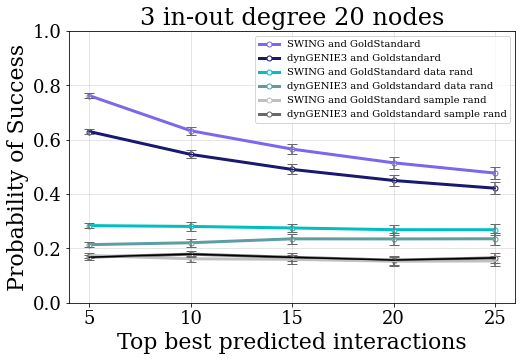

In [5]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes20_top{top}"])/top for top in Top]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes20_top{top}"])/top for top in Top]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes20_top{top}"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes20_top{top}"])/100 for top in Top]

mean_SWING_GoldStandard_rand = [mean(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes20_top{top}_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_rand = [mean(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes20_top{top}_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_rand = [std(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes20_top{top}_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_rand = [std(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes20_top{top}_rand"])/100 for top in Top]

mean_SWING_GoldStandard_sample_rand = [mean(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes20_top{top}_sample_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_sample_rand = [mean(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes20_top{top}_sample_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_sample_rand = [std(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes20_top{top}_sample_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_sample_rand = [std(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes20_top{top}_sample_rand"])/100 for top in Top]

plt.plot(Top, mean_SWING_GoldStandard, marker = "o", markersize = 5, lw = 3, color = "mediumslateblue", markerfacecolor = "w", label = "SWING and GoldStandard")
plt.errorbar(Top, mean_SWING_GoldStandard,yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray',color = "mediumslateblue")

plt.plot(Top, mean_dynGENIE3_GoldStandard, marker = "o", markersize = 5, lw =3, color = "midnightblue", markerfacecolor = "w", label = "dynGENIE3 and Goldstandard")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard, yerr=mean_dynGENIE3_GoldStandard_std,capsize=5,ecolor='dimgray',color = "midnightblue")

plt.plot(Top, mean_SWING_GoldStandard_rand, marker = "o", markersize = 5, lw = 3, color = "c", markerfacecolor = "w", label = "SWING and GoldStandard data rand")
plt.errorbar(Top, mean_SWING_GoldStandard_rand,yerr=mean_SWING_GoldStandard_std_rand,capsize=5,ecolor='dimgray',color = "c")

plt.plot(Top, mean_dynGENIE3_GoldStandard_rand, marker = "o", markersize = 5, lw =3, color = "cadetblue", markerfacecolor = "w", label = "dynGENIE3 and Goldstandard data rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_rand, yerr=mean_dynGENIE3_GoldStandard_std_rand, capsize=5,ecolor='dimgray',color = "cadetblue")

plt.plot(Top, mean_SWING_GoldStandard_sample_rand, marker = "o", markersize = 5, lw = 3, color = "silver", markerfacecolor = "w", label = "SWING and GoldStandard sample rand")
plt.errorbar(Top, mean_SWING_GoldStandard_sample_rand,yerr=mean_SWING_GoldStandard_std_sample_rand,capsize=5,ecolor='dimgray',color = "silver")

plt.plot(Top, mean_dynGENIE3_GoldStandard_sample_rand, marker = "o", markersize = 5, lw =3, color = "dimgray", markerfacecolor = "w", label = "dynGENIE3 and Goldstandard sample rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_sample_rand, yerr=mean_dynGENIE3_GoldStandard_std_sample_rand, capsize=5,ecolor='dimgray',color = "k")

plt.xlabel("Top best predicted interactions",fontsize = 22)
plt.ylabel("Probability of Success",fontsize = 22)
plt.legend(prop={"size":10, "family":"serif"})
plt.title("3 in-out degree 20 nodes", fontsize = 24)
plt.ylim(0,1)
plt.grid(alpha = 0.4)

## 50 nodes

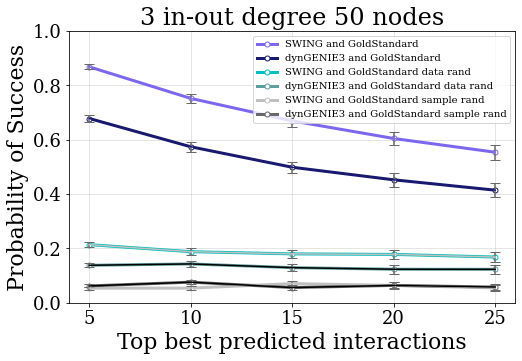

In [6]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes50_top{top}"])/top for top in Top]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes50_top{top}"])/top for top in Top]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes50_top{top}"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes50_top{top}"])/100 for top in Top]

mean_SWING_GoldStandard_rand = [mean(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes50_top{top}_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_rand = [mean(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes50_top{top}_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_rand = [std(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes50_top{top}_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_rand = [std(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes50_top{top}_rand"])/100 for top in Top]

mean_SWING_GoldStandard_sample_rand = [mean(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes50_top{top}_sample_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_sample_rand = [mean(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes50_top{top}_sample_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_sample_rand = [std(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes50_top{top}_sample_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_sample_rand = [std(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes50_top{top}_sample_rand"])/100 for top in Top]

plt.plot(Top, mean_SWING_GoldStandard, marker = "o", markersize = 5, lw = 3, color = "mediumslateblue", markerfacecolor = "w", label = "SWING and GoldStandard")
plt.errorbar(Top, mean_SWING_GoldStandard,yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray',color = "mediumslateblue")

plt.plot(Top, mean_dynGENIE3_GoldStandard, marker = "o", markersize = 5, lw =3, color = "midnightblue", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard, yerr=mean_dynGENIE3_GoldStandard_std,capsize=5,ecolor='dimgray',color = "midnightblue")

plt.plot(Top, mean_SWING_GoldStandard_rand, marker = "o", markersize = 5, lw = 3, color = "c", markerfacecolor = "w", label = "SWING and GoldStandard data rand")
plt.errorbar(Top, mean_SWING_GoldStandard_rand,yerr=mean_SWING_GoldStandard_std_rand,capsize=5,ecolor='dimgray',color = "silver")

plt.plot(Top, mean_dynGENIE3_GoldStandard_rand, marker = "o", markersize = 5, lw =3, color = "cadetblue", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard data rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_rand, yerr=mean_dynGENIE3_GoldStandard_std_rand, capsize=5,ecolor='dimgray',color = "k")

plt.plot(Top, mean_SWING_GoldStandard_sample_rand, marker = "o", markersize = 5, lw = 3, color = "silver", markerfacecolor = "w", label = "SWING and GoldStandard sample rand")
plt.errorbar(Top, mean_SWING_GoldStandard_sample_rand,yerr=mean_SWING_GoldStandard_std_sample_rand,capsize=5,ecolor='dimgray',color = "silver")

plt.plot(Top, mean_dynGENIE3_GoldStandard_sample_rand, marker = "o", markersize = 5, lw =3, color = "dimgray", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard sample rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_sample_rand, yerr=mean_dynGENIE3_GoldStandard_std_sample_rand, capsize=5,ecolor='dimgray',color = "k")

plt.xlabel("Top best predicted interactions",fontsize = 22)
plt.ylabel("Probability of Success",fontsize = 22)
plt.legend(prop={"size":10, "family":"serif"})
plt.title("3 in-out degree 50 nodes", fontsize = 24)
plt.ylim(0,1)
plt.grid(alpha = 0.4)

## 100 nodes

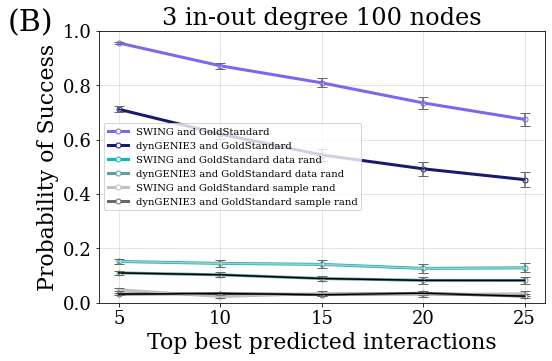

In [14]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes100_top{top}"])/top for top in Top]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes100_top{top}"])/top for top in Top]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes100_top{top}"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes100_top{top}"])/100 for top in Top]

mean_SWING_GoldStandard_rand = [mean(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes100_top{top}_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_rand = [mean(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes100_top{top}_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_rand = [std(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes100_top{top}_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_rand = [std(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes100_top{top}_rand"])/100 for top in Top]

mean_SWING_GoldStandard_sample_rand = [mean(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes100_top{top}_sample_rand"])/top for top in Top]
mean_dynGENIE3_GoldStandard_sample_rand = [mean(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes100_top{top}_sample_rand"])/top for top in Top]

mean_SWING_GoldStandard_std_sample_rand = [std(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes100_top{top}_sample_rand"])/100 for top in Top]
mean_dynGENIE3_GoldStandard_std_sample_rand = [std(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes100_top{top}_sample_rand"])/100 for top in Top]

plt.plot(Top, mean_SWING_GoldStandard, marker = "o", markersize = 5, lw = 3, color = "mediumslateblue", markerfacecolor = "w", label = "SWING and GoldStandard")
plt.errorbar(Top, mean_SWING_GoldStandard,yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray',color = "mediumslateblue")

plt.plot(Top, mean_dynGENIE3_GoldStandard, marker = "o", markersize = 5, lw =3, color = "midnightblue", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard, yerr=mean_dynGENIE3_GoldStandard_std,capsize=5,ecolor='dimgray',color = "midnightblue")

plt.plot(Top, mean_SWING_GoldStandard_rand, marker = "o", markersize = 5, lw = 3, color = "c", markerfacecolor = "w", label = "SWING and GoldStandard data rand")
plt.errorbar(Top, mean_SWING_GoldStandard_rand,yerr=mean_SWING_GoldStandard_std_rand,capsize=5,ecolor='dimgray',color = "silver")

plt.plot(Top, mean_dynGENIE3_GoldStandard_rand, marker = "o", markersize = 5, lw =3, color = "cadetblue", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard data rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_rand, yerr=mean_dynGENIE3_GoldStandard_std_rand, capsize=5,ecolor='dimgray',color = "k")

plt.plot(Top, mean_SWING_GoldStandard_sample_rand, marker = "o", markersize = 5, lw = 3, color = "silver", markerfacecolor = "w", label = "SWING and GoldStandard sample rand")
plt.errorbar(Top, mean_SWING_GoldStandard_sample_rand,yerr=mean_SWING_GoldStandard_std_sample_rand,capsize=5,ecolor='dimgray',color = "silver")

plt.plot(Top, mean_dynGENIE3_GoldStandard_sample_rand, marker = "o", markersize = 5, lw =3, color = "dimgray", markerfacecolor = "w", label = "dynGENIE3 and GoldStandard sample rand")
plt.errorbar(Top, mean_dynGENIE3_GoldStandard_sample_rand, yerr=mean_dynGENIE3_GoldStandard_std_sample_rand, capsize=5,ecolor='dimgray',color = "k")

plt.xlabel("Top best predicted interactions",fontsize = 22)
plt.ylabel("Probability of Success",fontsize = 22)
plt.legend(prop={"size":10, "family":"serif"})
plt.title("3 in-out degree 100 nodes", fontsize = 24)
plt.ylim(0,1)
plt.text(-0.5,1, '(B)', family = "serif", fontsize= 30)
plt.grid(alpha = 0.4)

# 5 top selected, changing the number of nodes

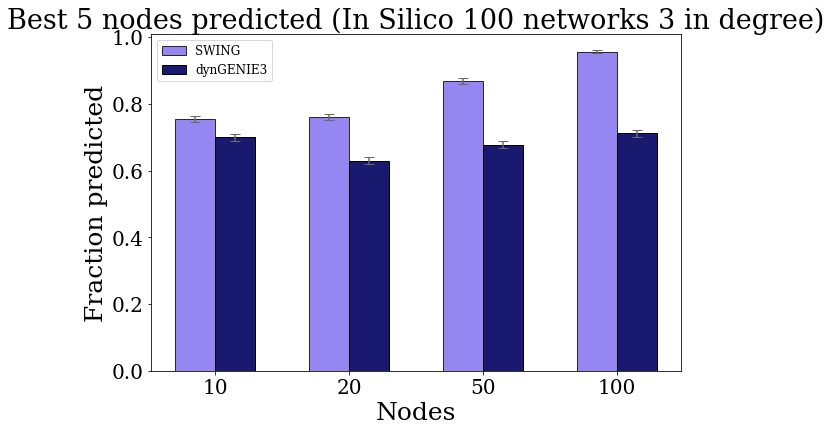

In [31]:
figure = plt.figure(figsize=(9.5,6.2))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top5"])/5 for nodes in Nodes]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top5"])/5 for nodes in Nodes]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top5"])/(100) for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top5"])/(100) for nodes in Nodes]

mean_SWING_GoldStandard_rand = [mean(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top5_rand"])/5 for nodes in Nodes]
mean_dynGENIE3_GoldStandard_rand = [mean(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top5_rand"])/5 for nodes in Nodes]

mean_SWING_GoldStandard_std_rand = [std(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top5_rand"])/(100) for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std_rand = [std(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top5_rand"])/(100) for nodes in Nodes]

mean_SWING_GoldStandard_sample_rand = [mean(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top5_sample_rand"])/5 for nodes in Nodes]
mean_dynGENIE3_GoldStandard_sample_rand = [mean(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top5_sample_rand"])/5 for nodes in Nodes]

mean_SWING_GoldStandard_std_sample_rand = [std(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top5_sample_rand"])/(100) for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std_sample_rand = [std(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top5_sample_rand"])/(100) for nodes in Nodes]

barWidth = 0.15

# Set position of bar on X axis
br1 = np.arange(len(mean_SWING_GoldStandard))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]

plt.bar(br1, mean_SWING_GoldStandard, yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray', align='center',color='mediumslateblue',alpha=0.6, width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, mean_dynGENIE3_GoldStandard,yerr=mean_dynGENIE3_GoldStandard_std,capsize=5, ecolor='dimgray',align='center', color='midnightblue', width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br3, mean_SWING_GoldStandard_rand, yerr=mean_SWING_GoldStandard_std_rand,capsize=5,ecolor='dimgray', align='center',color='c',alpha=0.6, width= barWidth, edgecolor= 'k', label='SWING data crand')
plt.bar(br4, mean_dynGENIE3_GoldStandard_rand,yerr=mean_dynGENIE3_GoldStandard_std_rand,capsize=5, ecolor='dimgray',align='center', color='cadetblue', width= barWidth, edgecolor= 'k', label='dynGENIE3 data crand')
plt.bar(br5, mean_SWING_GoldStandard_sample_rand, yerr=mean_SWING_GoldStandard_std_sample_rand,capsize=5,ecolor='dimgray', align='center',color='silver',alpha=0.76, width= barWidth, edgecolor= 'k', label='SWING sample rand')
plt.bar(br6, mean_dynGENIE3_GoldStandard_sample_rand,yerr=mean_dynGENIE3_GoldStandard_std_sample_rand,capsize=5, ecolor='dimgray',align='center', color='grey', width= barWidth, edgecolor= 'k', label='dynGENIE3 sample rand')

plt.xticks([r + barWidth + 0.225 for r in range(len(mean_SWING_GoldStandard))], ["10", "20", "50", "100"])
plt.xlabel("Nodes in the network",fontsize = 21)
plt.ylabel("Predicted fraction",fontsize = 21)
plt.title("Best 5 interactions predicted (In Silico 100 networks 3 in degree)", fontsize = 22)
plt.ylim(0,1.01)
plt.legend(prop={"size":9, "family":"serif"})

# 10 top selected, changing the number of nodes

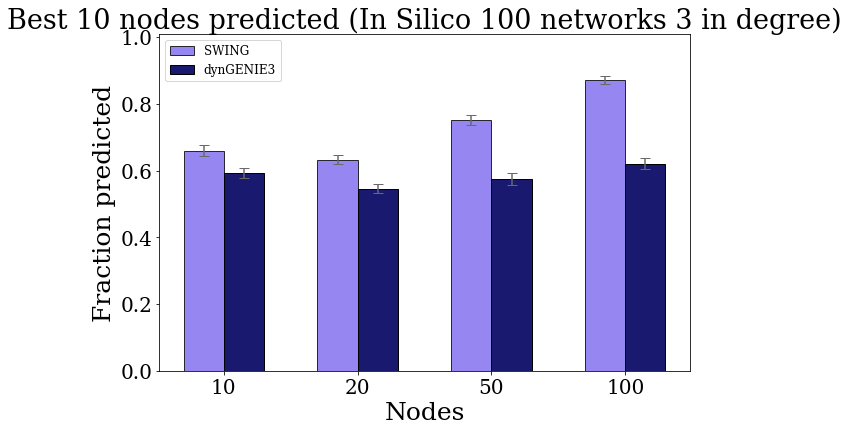

In [32]:
figure = plt.figure(figsize=(9.5,6.2))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top10"])/10 for nodes in Nodes]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top10"])/10 for nodes in Nodes]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top10"])/(100) for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top10"])/(100) for nodes in Nodes]

mean_SWING_GoldStandard_rand = [mean(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top10_rand"])/10 for nodes in Nodes]
mean_dynGENIE3_GoldStandard_rand = [mean(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top10_rand"])/10 for nodes in Nodes]

mean_SWING_GoldStandard_std_rand = [std(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top10_rand"])/(100) for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std_rand = [std(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top10_rand"])/(100) for nodes in Nodes]

mean_SWING_GoldStandard_sample_rand = [mean(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top10_sample_rand"])/10 for nodes in Nodes]
mean_dynGENIE3_GoldStandard_sample_rand = [mean(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top10_sample_rand"])/10 for nodes in Nodes]

mean_SWING_GoldStandard_std_sample_rand = [std(list_sum_SWING_GoldStandard_sample_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top10_sample_rand"])/(100) for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std_sample_rand = [std(list_sum_dynGENIE3_GoldStandard_sample_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top10_sample_rand"])/(100) for nodes in Nodes]

barWidth = 0.15

# Set position of bar on X axis
br1 = np.arange(len(mean_SWING_GoldStandard))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]

plt.bar(br1, mean_SWING_GoldStandard, yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray', align='center',color='mediumslateblue',alpha=0.6, width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, mean_dynGENIE3_GoldStandard,yerr=mean_dynGENIE3_GoldStandard_std,capsize=5, ecolor='dimgray',align='center', color='midnightblue', width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br3, mean_SWING_GoldStandard_rand, yerr=mean_SWING_GoldStandard_std_rand,capsize=5,ecolor='dimgray', align='center',color='c',alpha=0.6, width= barWidth, edgecolor= 'k', label='SWING data crand')
plt.bar(br4, mean_dynGENIE3_GoldStandard_rand,yerr=mean_dynGENIE3_GoldStandard_std_rand,capsize=5, ecolor='dimgray',align='center', color='cadetblue', width= barWidth, edgecolor= 'k', label='dynGENIE3 data crand')
plt.bar(br5, mean_SWING_GoldStandard_sample_rand, yerr=mean_SWING_GoldStandard_std_sample_rand,capsize=5,ecolor='dimgray', align='center',color='silver',alpha=0.76, width= barWidth, edgecolor= 'k', label='SWING sample rand')
plt.bar(br6, mean_dynGENIE3_GoldStandard_sample_rand,yerr=mean_dynGENIE3_GoldStandard_std_sample_rand,capsize=5, ecolor='dimgray',align='center', color='grey', width= barWidth, edgecolor= 'k', label='dynGENIE3 sample rand')

plt.xticks([r + barWidth + 0.225 for r in range(len(mean_SWING_GoldStandard))], ["10", "20", "50", "100"])
plt.xlabel("Nodes in the network",fontsize = 21)
plt.ylabel("Predicted fraction",fontsize = 21)
plt.title("Best 10 interactions predicted (In Silico 100 networks 3 in degree)", fontsize = 22)
plt.ylim(0,1.01)
plt.legend(prop={"size":9, "family":"serif"})

# 15 top selected, changing the number of nodes

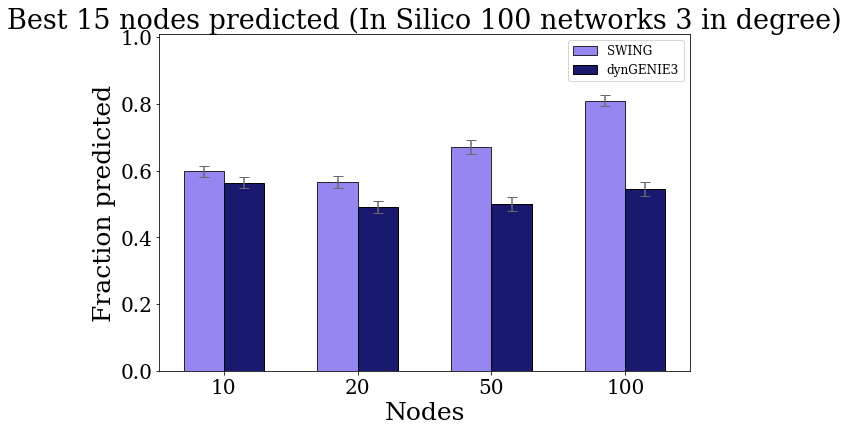

In [33]:
figure = plt.figure(figsize=(9.5,6.2))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top15"])/15 for nodes in Nodes]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top15"])/15 for nodes in Nodes]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top15"])/100 for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top15"])/100 for nodes in Nodes]

mean_SWING_GoldStandard_rand = [mean(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top15_rand"])/15 for nodes in Nodes]
mean_dynGENIE3_GoldStandard_rand = [mean(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top15_rand"])/15 for nodes in Nodes]

mean_SWING_GoldStandard_std_rand = [std(list_sum_SWING_GoldStandard_rand[f"list_sum_SWING_GoldStandard_nodes{nodes}_top15_rand"])/(100) for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std_rand = [std(list_sum_dynGENIE3_GoldStandard_rand[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top15_rand"])/(100) for nodes in Nodes]

barWidth = 0.2

# Set position of bar on X axis
br1 = np.arange(len(mean_SWING_GoldStandard))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]

plt.bar(br1, mean_SWING_GoldStandard, yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray', align='center',color='mediumslateblue',alpha=0.8, width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, mean_dynGENIE3_GoldStandard,yerr=mean_dynGENIE3_GoldStandard_std,capsize=5, ecolor='dimgray',align='center', color='midnightblue', width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br3, mean_SWING_GoldStandard_rand, yerr=mean_SWING_GoldStandard_std_rand,capsize=5,ecolor='dimgray', align='center',color='grey', width= barWidth, edgecolor= 'k', label='SWING crand')
plt.bar(br4, mean_dynGENIE3_GoldStandard_rand,yerr=mean_dynGENIE3_GoldStandard_std_rand,capsize=5, ecolor='dimgray',align='center', color='silver', width= barWidth, edgecolor= 'k', label='dynGENIE3 crand')

plt.xticks([r + barWidth - 0.15 for r in range(len(mean_SWING_GoldStandard))], ["10", "20", "50", "100"])
plt.xlabel("Nodes",fontsize = 21)
plt.ylabel("Predicted fraction",fontsize = 21)
plt.title("Best 15 nodes predicted (In Silico 100 networks 3 in degree)", fontsize = 22)
plt.ylim(0,1.01)
plt.legend(prop={"size":12, "family":"serif"})

# 20 top selected, changing the number of nodes

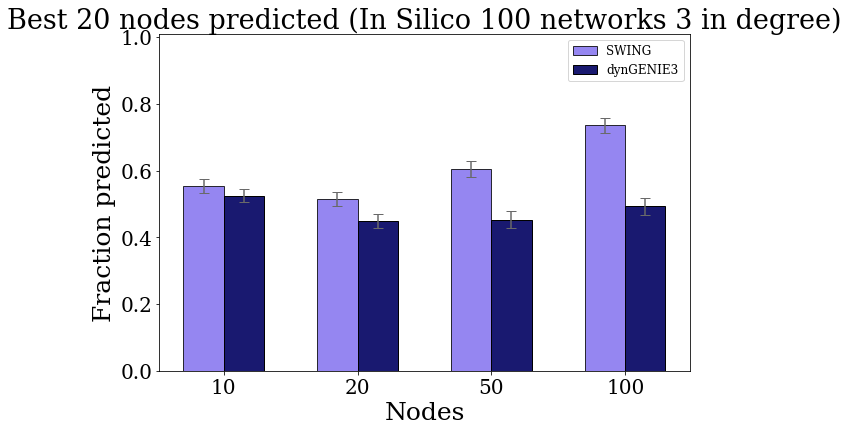

In [34]:
figure = plt.figure(figsize=(9.5,6.2))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rcParams["font.family"] = "serif"

mean_SWING_GoldStandard = [mean(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top20"])/20 for nodes in Nodes]
mean_dynGENIE3_GoldStandard = [mean(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top20"])/20 for nodes in Nodes]

mean_SWING_GoldStandard_std = [std(list_sum_SWING_GoldStandard[f"list_sum_SWING_GoldStandard_nodes{nodes}_top20"])/100 for nodes in Nodes]
mean_dynGENIE3_GoldStandard_std = [std(list_sum_dynGENIE3_GoldStandard[f"list_sum_dynGENIE3_GoldStandard_nodes{nodes}_top20"])/100 for nodes in Nodes]

barWidth = 0.3

# Set position of bar on X axis
br1 = np.arange(len(mean_SWING_GoldStandard))
br2 = [x + barWidth for x in br1]


plt.bar(br1, mean_SWING_GoldStandard, yerr=mean_SWING_GoldStandard_std,capsize=5,ecolor='dimgray', align='center',color='mediumslateblue',alpha=0.8, width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, mean_dynGENIE3_GoldStandard,yerr=mean_dynGENIE3_GoldStandard_std,capsize=5, ecolor='dimgray',align='center', color='midnightblue', width= barWidth, edgecolor= 'k', label='dynGENIE3')

plt.xticks([r + barWidth - 0.15 for r in range(len(mean_SWING_GoldStandard))], ["10", "20", "50", "100"])
plt.xlabel("Nodes",fontsize = 25)
plt.ylabel("Fraction predicted",fontsize = 25)
plt.title("Best 20 nodes predicted (In Silico 100 networks 3 in degree)", fontsize = 27)
plt.ylim(0,1.01)
plt.legend(prop={"size":12, "family":"serif"})